In [9]:
# Importing the necessary libraries
import torch
from torch import optim, utils, tensor, nn

import matplotlib.pyplot as plt
from getdist import plots, MCSamples

from Network import Generator, Discriminator
from Signal_Generator import *

from tqdm import tqdm

# Setting the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
# Defining the hyperparameters
datasize = 16000
num_sources = 2
noise_amplitude = 0
freq_range = (1e-4, 1e-1)
total_time = 1000

num_latent_variables = 20
learning_rate = 1e-5
weight_clip = 0.1

d_loss_threshold = -0.1
g_loss_threshold = -0.3
threshold_adjustment = 0.025
max_steps = 300

num_epochs = 500

In [11]:
# Defining the distribution for amplitude and angular frequency
def amp_distribution(size):
    """
    Amplitude distribution using uniform distribution.
    """
    return np.random.uniform(4, 16, size=size)

def omega_distribution(size):
    """
    Angular frequency distribution using uniform distribution.
    """
    return np.random.uniform(2 * np.pi * 1e-4, 2 * np.pi * 1e-1, size=size)


In [12]:
dataset = torch.load('dataset.pt')

In [85]:
epochs = 3000
generator = torch.load(f'generator_epoch_{epochs}.pt')
Discriminator = torch.load(f'discriminator_epoch_{epochs}.pt')

generator.eval()

Generator(
  (init_conv): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (init_relu): LeakyReLU(negative_slope=0.2)
  (res_block_no_norm): ResBlock(
    (conv1): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
    (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (leaky_relu): LeakyReLU(negative_slope=0.2)
  )
  (down1): Conditional_Down(
    (conv): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (relu): LeakyReLU(negative_slope=0.2)
    (avg_pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
    (res_block): Conditional_ResBlock(
      (conv1): Conv1d(128, 128, kernel_size=(1,), stride=(1,))
      (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (leaky_relu): LeakyReLU(negative_slope=0.2)
      (process1): CIN(
        (inst_norm): InstanceNorm1d(

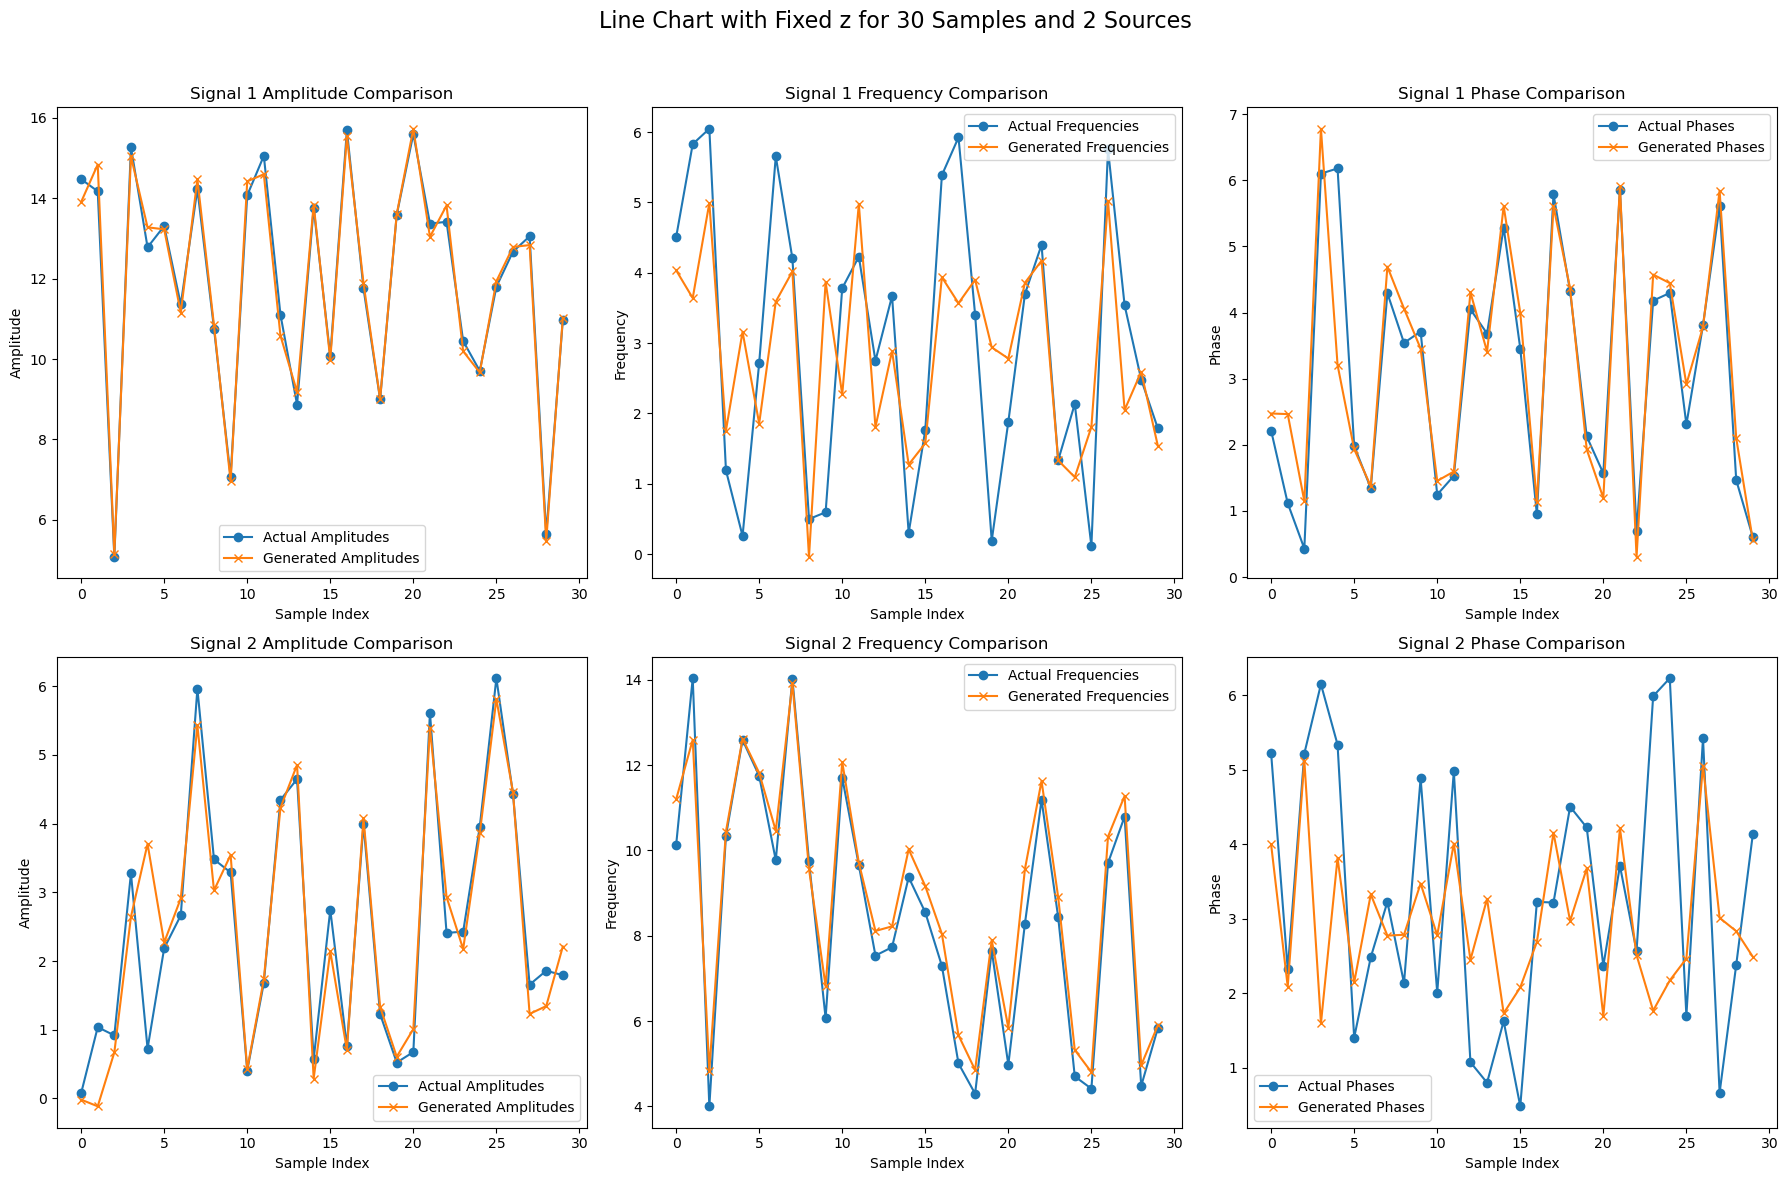

In [92]:
# Generating the parameters for line chart
params_list = []
generated_params_list = []

test_times = 30
for i in range(test_times):
    TS = Signal_Generator(num_sources=num_sources, noise_amplitude=noise_amplitude, freq_range=freq_range, total_time=total_time, amp_distribution_func=amp_distribution, omega_distribution_func=omega_distribution)
    test_data = TS.generating_signal()
    params = TS.printing_parameters()

    input_signal = test_data['Signal'].values
    input_signal_tensor = torch.tensor(input_signal, dtype=torch.float).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        z = torch.randn(1, num_latent_variables, 1).to(device)
        generated_params = generator(input_signal_tensor, z).squeeze().cpu().numpy()

    params_list.append(params)
    generated_params_list.append(generated_params)

actual_amplitudes = [[] for _ in range(num_sources)]
actual_frequencies = [[] for _ in range(num_sources)]
actual_phases = [[] for _ in range(num_sources)]

generated_amplitudes = [[] for _ in range(num_sources)]
generated_frequencies = [[] for _ in range(num_sources)]
generated_phases = [[] for _ in range(num_sources)]

for params in params_list:
    for i in range(num_sources):
        actual_amplitudes[i].append(params[i])
        actual_frequencies[i].append(params[num_sources + i])
        actual_phases[i].append(params[2 * num_sources + i])

for gen_params in generated_params_list:
    for i in range(num_sources):
        generated_amplitudes[i].append(gen_params[i])
        generated_frequencies[i].append(gen_params[num_sources + i])
        generated_phases[i].append(gen_params[2 * num_sources + i])

plt.figure(figsize=(18, 6 * num_sources))

for i in range(num_sources):
    plt.subplot(num_sources, 3, 3 * i + 1)
    plt.plot(range(test_times), actual_amplitudes[i], 'o-', label='Actual Amplitudes')
    plt.plot(range(test_times), generated_amplitudes[i], 'x-', label='Generated Amplitudes')
    plt.xlabel('Sample Index')
    plt.ylabel('Amplitude')
    plt.title(f'Signal {i+1} Amplitude Comparison')
    plt.legend()

    plt.subplot(num_sources, 3, 3 * i + 2)
    plt.plot(range(test_times), actual_frequencies[i], 'o-', label='Actual Frequencies')
    plt.plot(range(test_times), generated_frequencies[i], 'x-', label='Generated Frequencies')
    plt.xlabel('Sample Index')
    plt.ylabel('Frequency')
    plt.title(f'Signal {i+1} Frequency Comparison')
    plt.legend()

    plt.subplot(num_sources, 3, 3 * i + 3)
    plt.plot(range(test_times), actual_phases[i], 'o-', label='Actual Phases')
    plt.plot(range(test_times), generated_phases[i], 'x-', label='Generated Phases')
    plt.xlabel('Sample Index')
    plt.ylabel('Phase')
    plt.title(f'Signal {i+1} Phase Comparison')
    plt.legend()

plt.suptitle(f'Line Chart with Fixed z for {test_times} Samples and {num_sources} Sources', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])


[9.645283442845571, 0.3718003704631246, 0.37836750067923147, 4.105517824346961, 5.619446895988905, 4.2769660640508835]
[array([9.865011 , 0.6820978, 1.9562546, 4.376864 , 5.6066437, 1.0873793],
      dtype=float32), array([9.944169  , 0.63675916, 1.9030684 , 4.093197  , 5.285028  ,
       1.8357923 ], dtype=float32), array([9.752568  , 0.68897736, 1.8445044 , 4.1588616 , 5.62402   ,
       1.241085  ], dtype=float32), array([10.229528 ,  0.7336171,  0.752391 ,  4.028018 ,  5.1016984,
        2.0634804], dtype=float32), array([9.619251  , 0.02889054, 1.2130164 , 4.0792823 , 5.905338  ,
       0.17537414], dtype=float32), array([9.749214  , 1.0306301 , 1.5937024 , 4.8863645 , 5.298416  ,
       0.97272265], dtype=float32), array([9.443759 , 0.3940302, 2.5449371, 4.1839232, 5.519548 , 0.9223443],
      dtype=float32), array([9.55399   , 0.63858026, 2.504707  , 4.568071  , 5.5040555 ,
       1.2584321 ], dtype=float32), array([10.033387  ,  0.47963744,  1.9988967 ,  4.507589  ,  5.6078796 

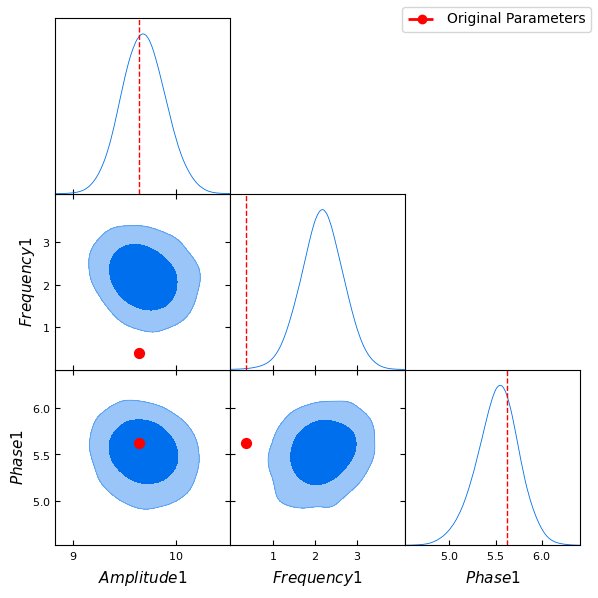

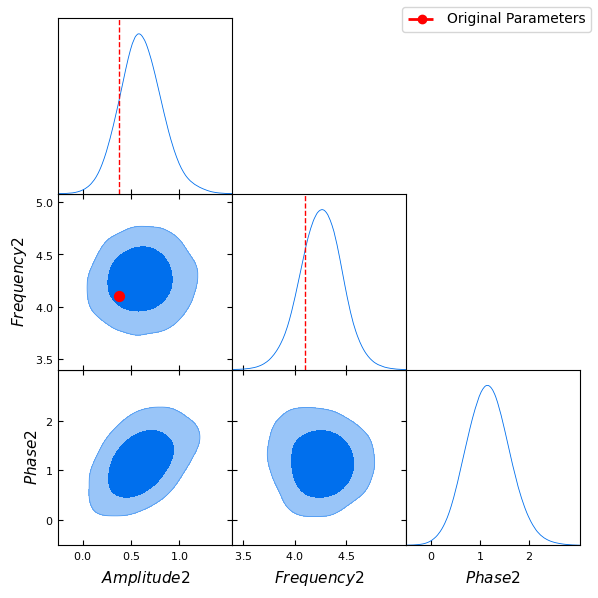

In [ ]:
# Generating the parameters for triangle graph
generated_params_list = []

TS = Signal_Generator(num_sources=num_sources, noise_amplitude=noise_amplitude, freq_range=freq_range, 
                      total_time=total_time, amp_distribution_func=amp_distribution, omega_distribution_func=omega_distribution)
test_data = TS.generating_signal()
params = TS.printing_parameters()

input_signal = test_data['Signal'].values
input_signal_tensor = torch.tensor(input_signal, dtype=torch.float).unsqueeze(0).unsqueeze(0).to(device)

for i in range(10000):
    with torch.no_grad():
        z = torch.randn(1, num_latent_variables, 1).to(device)
        generated_params = generator(input_signal_tensor, z).squeeze().cpu().numpy()

    generated_params_list.append(generated_params)

print(params)
print(generated_params_list)

columns = []
for i in range(num_sources):
    columns.extend([f'Amplitude{i+1}', f'Frequency{i+1}', f'Phase{i+1}'])

generated_params_df = pd.DataFrame(generated_params_list, columns=columns)

for i in range(num_sources):
    amplitude_idx = i
    frequency_idx = num_sources + i
    phase_idx = 2 * num_sources + i
    param_slice = [params[amplitude_idx], params[frequency_idx], params[phase_idx]]
    
    names = [f"A{i+1}", f"omega{i+1}", f"theta{i+1}"]
    labels = [f"Amplitude{i+1}", f"Frequency{i+1}", f"Phase{i+1}"]

    generated_params_samples = MCSamples(samples=generated_params_df.iloc[:, [amplitude_idx, frequency_idx, phase_idx]].values, names=names, labels=labels, settings={'ignore_rows': 1000})
    generated_params_samples.updateSettings({'fine_bins_2D': 1048})

    g = plots.get_subplot_plotter()

    g.triangle_plot([generated_params_samples], filled=True)

    axes = g.subplots

    for j in range(len(names)):
        for k in range(j + 1, len(names)):
            ax = axes[k, j]
            if ax is not None:
                ax.scatter(param_slice[j], param_slice[k], color='red', marker='o', s=50)

    for j in range(len(names)):
        ax = axes[j, j]
        if ax is not None:
            ax.axvline(param_slice[j], linestyle='--', color='red', lw=1)

    handles = [plt.Line2D([0], [0], color='red', lw=2, linestyle='--', marker='o')]
    labels = ['Original Parameters']
    g.fig.legend(handles, labels, loc='upper right')